# GreenTravel Intelligence Challenge - HighCarbon Prediction

## Objective

The goal of this notebook is to predict whether a business trip will be classified as HighCarbon before it is booked using only the datasets provided in the challenge.

Instead of creating a large number of features,focused on understanding what mainly affects carbon emissions.





## Load the data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

train = pd.read_csv('public_trip_data.csv')
test  = pd.read_csv('private_trip_data.csv')

print(train.shape, test.shape)
train.head()

(65289, 20) (21764, 13)


,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,EmployeeNumber,BusinessUnit,HotelNights,NetCosts,Departure_CO2e,Return_CO2e,Hotel_CO2e,Spend_CO2e,TotalCO2e,HighCarbon
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,M1000-M5008,Services,1,900,1565.121857,1565.121857,58.9,1472.279257,3189.143714,0
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,M1000-M5030,Sales,2,3600,743.295848,743.295848,38.6,2921.504761,1525.191696,0
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,M1000-M5069,Services,1,450,1053.713528,1053.713528,51.4,743.646219,2158.827056,0
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,M1000-M5095,Executive Management,1,3450,196.262703,196.262703,6.7,3343.160260,399.225407,0
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,M1000-M5097,Marketing,2,1500,1053.713528,1053.713528,102.8,2478.820729,2210.227056,0


# Exploratory Data Analysis
## Checking the target first

Before doing anything else I wanted to see how balanced `HighCarbon` is.

In [2]:
train['HighCarbon'].value_counts(normalize=True).round(3)

HighCarbon
0    0.75
1    0.25
Name: proportion, dtype: float64

~25% of trips are HighCarbon. Not badly imbalanced, so I didn't need any resampling.

## Does it matter if the trip is domestic?

My guess was that a trip within the same country would almost never be high carbon -
short distance, usually a car or train. I checked it.

In [3]:
train['domestic'] = (train.DepartureLocationCountry == train.ArrivalLocationCountry).astype(int)
train.groupby('domestic')['HighCarbon'].agg(['mean', 'count'])

,mean,count
domestic,,
0,0.27306,59789
1,0.00000,5500


I was right - domestic trips are basically never HighCarbon. One of the strongest single signals in the whole dataset, and it's a one-line feature.

## Does transport mode matter?

Next I looked at the different ShippingTypeDescription values.

In [4]:
train.groupby('ShippingTypeDescription')['HighCarbon'].agg(['mean', 'count']).sort_values('mean')

,mean,count
ShippingTypeDescription,,
Train,0.000000,3197
Fiat 500 electric,0.050938,1119
Volkswagen Golf diesel,0.052091,5452
Volkswagen Golf petrol,0.053256,4469
BMW 3 plugin hybrid,0.104450,1101
BMW 3 diesel,0.106649,6648
Economy Flight,0.213812,27295
Business Class Flight,0.563685,15035
First Class Flight,0.628983,973


Cars/train are low, Economy Flight is in the middle, Business/First Class Flight are
high. Makes sense - flying uses a lot more fuel per person than driving, and premium
seats take up more space (and weight) per passenger.

## What about the route (departure country -> arrival country)?

I don't have real distance data , so I used
the country-to-country pair as a rough stand-in for distance.

In [5]:
train['route'] = train.DepartureLocationCountry + '_' + train.ArrivalLocationCountry
route_stats = train.groupby('route')['HighCarbon'].agg(['mean', 'count']).sort_values('mean')
print(f"unique routes: {train['route'].nunique()}")
route_stats

unique routes: 32


,mean,count
route,,
AU_AU,0.000000,3499
AU_NZ,0.000000,610
BR_AR,0.000000,3225
DE_NL,0.000000,1410
ZA_ZA,0.000000,1411
US_CA,0.000000,2999
MX_US,0.000000,2016
US_MX,0.000000,3231
JP_JP,0.000000,273


Only 32 unique routes, and each one has a decent number of trips behind it, so I felt okay using this as a real feature.

## Do Purpose, BusinessUnit, or EntitiyCode matter?

I expected these to be weak - they're more about how the company tags a trip
internally than about how the trip physically happens.

In [6]:
for col in ['Purpose', 'BusinessUnit', 'EntitiyCode']:
    rates = train.groupby(col)['HighCarbon'].mean()
    print(f"{col:12s} min={rates.min():.3f} max={rates.max():.3f}  (base rate = 0.250)")

Purpose      min=0.247 max=0.254  (base rate = 0.250)
BusinessUnit min=0.226 max=0.309  (base rate = 0.250)
EntitiyCode  min=0.245 max=0.255  (base rate = 0.250)


All three stay close to the 25% base rate. I decided to leave them out of the model - I'd rather test and drop a feature than keep it just because it was there.

## Is the event log actually useful?

There's a lot in the event log - delays, cancellations, approvals, extensions. It's
tempting to build a pile of features out of it, but before doing that I wanted to check
if any of it actually relates to HighCarbon.

In [7]:
log = pd.read_csv('public_trip_event_log.csv')
log['EventTimestamp'] = pd.to_datetime(log['EventTimestamp'], format='%m/%d/%Y %H:%M:%S')

# one row per trip: number of events + how long the process took
agg = log.groupby('TripID').agg(
    n_events=('EventName', 'count'),
    duration_hours=('EventTimestamp', lambda x: (x.max() - x.min()).total_seconds() / 3600)
)

# flag for whether each event type happened at all for a trip
flags = log.pivot_table(index='TripID', columns='EventName', aggfunc='size', fill_value=0)
flags = (flags > 0).astype(int).add_prefix('has_')

process = agg.join(flags)
m = train.merge(process, on='TripID')

behave_cols = ['n_events', 'duration_hours', 'has_Flight Delay', 'has_Flight Cancellation',
               'has_Missed Flight', 'has_Flight Change', 'has_Trip Extension',
               'has_Itinerary Edit', 'has_Expense Request Denied']
m[behave_cols].corrwith(m['HighCarbon']).sort_values()

n_events                     -0.007967
duration_hours               -0.006517
has_Itinerary Edit           -0.000680
has_Trip Extension            0.001520
has_Expense Request Denied    0.002308
has_Missed Flight             0.021657
has_Flight Delay              0.025161
has_Flight Cancellation       0.026500
has_Flight Change             0.046500
dtype: float64

Everything is under 0.05 correlation. Kind of makes sense when I think about it - a flight getting delayed doesn't change how much fuel it burned.

In [8]:
# double check with an actual model comparison instead of just correlation
train['is_flight'] = train.ShippingTypeDescription.str.contains('Flight').astype(int)
train['out_of_policy'] = (train.OutOfPolicy == 'Yes').astype(int)
train['cost_per_night'] = train.NetCosts / train.HotelNights

base_cols = ['is_flight', 'domestic', 'HotelNights', 'NetCosts', 'cost_per_night', 'out_of_policy']
m2 = train.merge(process, on='TripID')

cv = StratifiedKFold(5, shuffle=True, random_state=42)
probe = GradientBoostingClassifier(random_state=42, n_estimators=150, max_depth=3, learning_rate=0.1)

s1 = cross_val_score(probe, m2[base_cols], m2['HighCarbon'], cv=cv, scoring='roc_auc')
s2 = cross_val_score(probe, m2[base_cols + behave_cols], m2['HighCarbon'], cv=cv, scoring='roc_auc')

print(f"without event log: {s1.mean():.5f}")
print(f"with event log:    {s2.mean():.5f}")

without event log: 0.73144
with event log:    0.72957


AUC didn't go up (if anything it went slightly down). Based on this I decided not to use the event log at all for this target. Feels like a waste of a whole file, but I'd rather keep the model clean than add features that don't do anything.

# Feature Engineering
## Building my features

Here's what I ended up with, and why each one is there:

- `route_te` - average HighCarbon rate for that specific departure->arrival country pair, calculated only from training folds (explained below)
- `ship_te` - same idea, but for shipping type
- `is_flight` - 1/0, is it a flight at all
- `domestic` - 1/0, same country
- `HotelNights`, `NetCosts` - used as given
- `cost_per_night` - NetCosts / HotelNights, wanted to see if "expensive per night" behaves differently from just "expensive"
- `out_of_policy` - 1/0 from the OutOfPolicy column

One decision I want to call out: I didn't hand-rank flight class myself (Economy < Business < First). Instead `ship_te` learns that ordering straight from the HighCarbon rates in the data. Felt more honest than me guessing the order, even though I'm pretty sure I'd have guessed it right.

In [9]:
def target_encode(train_df, test_df, col, target='HighCarbon', folds=5, smooth=10, seed=42):
    # average target rate per category, done out-of-fold so we don't leak the row's own label into itself
    global_mean = train_df[target].mean()
    oof = np.zeros(len(train_df))
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)

    for tr_idx, val_idx in skf.split(train_df, train_df[target]):
        stats = train_df.iloc[tr_idx].groupby(col)[target].agg(['mean', 'count'])
        smoothed = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
        oof[val_idx] = train_df.iloc[val_idx][col].map(smoothed).fillna(global_mean).values

    # for the actual test set, use stats from the full training data
    stats_full = train_df.groupby(col)[target].agg(['mean', 'count'])
    smoothed_full = (stats_full['mean'] * stats_full['count'] + global_mean * smooth) / (stats_full['count'] + smooth)
    test_enc = test_df[col].map(smoothed_full).fillna(global_mean).values

    return oof, test_enc


def add_features(df):
    df = df.copy()
    df['domestic'] = (df.DepartureLocationCountry == df.ArrivalLocationCountry).astype(int)
    df['is_flight'] = df.ShippingTypeDescription.str.contains('Flight').astype(int)
    df['out_of_policy'] = (df.OutOfPolicy == 'Yes').astype(int)
    df['cost_per_night'] = df.NetCosts / df.HotelNights
    df['route'] = df.DepartureLocationCountry + '_' + df.ArrivalLocationCountry
    return df

train = pd.read_csv('public_trip_data.csv')
test  = pd.read_csv('private_trip_data.csv')
train = add_features(train)
test  = add_features(test)

train['route_te'], test['route_te'] = target_encode(train, test, 'route')
train['ship_te'],  test['ship_te']  = target_encode(train, test, 'ShippingTypeDescription')

feats = ['route_te', 'ship_te', 'is_flight', 'domestic', 'HotelNights',
         'NetCosts', 'cost_per_night', 'out_of_policy']
print(len(feats), 'features:', feats)

8 features: ['route_te', 'ship_te', 'is_flight', 'domestic', 'HotelNights', 'NetCosts', 'cost_per_night', 'out_of_policy']


## Final Check

Just making sure I didn't accidentally leave in something I'm not allowed to use.

In [10]:
banned = {'Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e', 'TotalCO2e', 'HighCarbon'}
assert banned.isdisjoint(set(feats))
assert set(feats).issubset(set(train.columns))
print("ok, no banned columns in feats")

ok, no banned columns in feats


## Training the model

I went with Gradient Boosting, shallow trees (depth 3), not too many of them. I didn't
see a reason to go bigger - the signal from route + mode is already strong, so a more
complex model just feels like extra overfitting risk for no real gain.

In [11]:
X = train[feats]
y = train['HighCarbon']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = GradientBoostingClassifier(random_state=42, n_estimators=200, max_depth=3, learning_rate=0.08)

scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.5f} (+/- {scores.std():.5f})")

CV AUC: 0.99821 (+/- 0.00090)


## Precision / recall / F1

AUC is the main metric here, but I also wanted to see how the model does at a normal
0.5 cutoff, since that's the number I'd actually have to defend if someone asked
whether this would catch real high-carbon trips.

In [12]:
pred_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
pred = (pred_proba >= 0.5).astype(int)

print(f"AUC:       {roc_auc_score(y, pred_proba):.5f}")
print(f"Precision: {precision_score(y, pred):.5f}")
print(f"Recall:    {recall_score(y, pred):.5f}")
print(f"F1:        {f1_score(y, pred):.5f}")
print(confusion_matrix(y, pred))

AUC:       0.99770
Precision: 0.98537
Recall:    0.96515
F1:        0.97515
[[48729   234]
 [  569 15757]]


## How much of this is coming from route/mode?

I wanted to check what happens if I strip out `route_te`, `ship_te` and `is_flight` -
basically remove anything related to distance or transport mode and see what's left.

In [13]:
minimal = ['HotelNights', 'NetCosts', 'cost_per_night', 'out_of_policy', 'domestic']
s_min = cross_val_score(model, train[minimal], y, cv=cv, scoring='roc_auc')
s_full = cross_val_score(model, train[feats], y, cv=cv, scoring='roc_auc')

print(f"full feature set:        {s_full.mean():.5f}")
print(f"without route/mode info: {s_min.mean():.5f}")

full feature set:        0.99821
without route/mode info: 0.63849


AUC drops a lot without route/mode. That tells me the model isn't picking up on some random pattern - it's mostly using the same signal I found earlier just by looking at the groupby tables. That's reassuring.

In [14]:
model.fit(X, y)
imp = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=False)
imp.round(6)

route_te          0.739842
ship_te           0.232599
HotelNights       0.019577
is_flight         0.007966
out_of_policy     0.000012
cost_per_night    0.000004
NetCosts          0.000001
domestic          0.000000
dtype: float64

`route_te` and `ship_te` are doing almost all of the work. Everything else adds a
small amount on top.

Two features I'd keep an eye on if this ever gets retrained on new data:
- `cost_per_night` is a ratio, and ratios can act weird on small groups. Its importance
  is basically zero right now, but I'm flagging it since that's the kind of feature
  that can misbehave later.
- `out_of_policy` is probably more of a side-effect than a cause - people booking
  business/first class get flagged out of policy more often, it's not that being out
  of policy causes emissions. If the company changes its policy rules, this feature
  might stop meaning the same thing.

## Fit on all the training data and predict on the private test set

In [15]:
model.fit(X, y)
test_proba = model.predict_proba(test[feats])[:, 1]

# Create submission directly
sub = pd.DataFrame({
    "TripID": test["TripID"],
    "HighCarbon": test_proba
})

sub.to_csv("submission.csv", index=False)
sub.head()

,TripID,HighCarbon
0,2,0.998043
1,4,0.016689
2,5,0.846777
3,14,0.001124
4,15,0.000194


## Model performance - ROC Curve

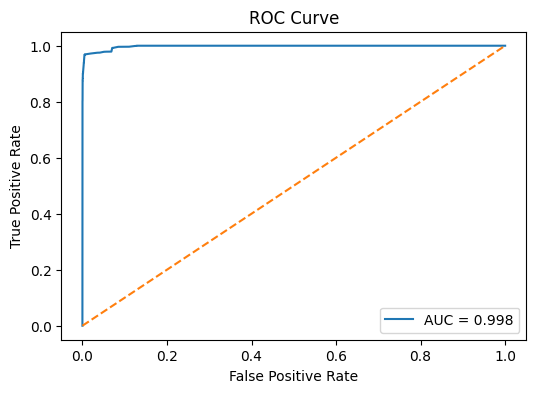

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
fpr, tpr, _ = roc_curve(y, pred_proba)
auc = roc_auc_score(y, pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

## Confusion Matrix

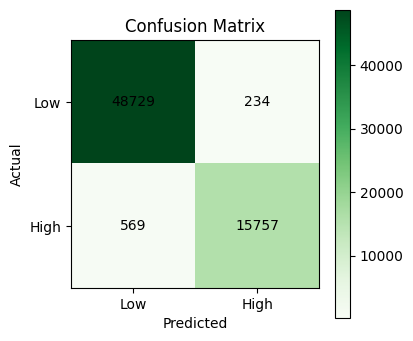

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y, pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Greens")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["Low", "High"])
plt.yticks([0,1], ["Low", "High"])

plt.colorbar()
plt.show()

## Conclusion

- 8 features, all built from the files I was given, nothing external
- ~0.998 CV AUC with a fairly simple, shallow model
- Every feature I dropped (event log, Purpose, BusinessUnit, EntitiyCode) I dropped
  because I tested it and it didn't help - not because I assumed it wouldn't
- Overall the model is mostly just learning "how far did this trip go, and what did
  they travel on" - which is what I'd expect if I think about how emissions actually
  get generated in the first place